In [ ]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("final_cleaned_data.csv")

df["log_price"] = np.log1p(df["cars_prices"]) 

y = df["log_price"]
X = df.drop(columns=["log_price", "cars_prices"])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])




In [ ]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)
print("RFRModel MAE:", rf_mae)
print("RFRModel RMSE:", rf_rmse)
print("RFRModel R²:", rf_r2) 


0.15120440923765013 0.21246058527714903 0.950165485004328


In [ ]:
param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}
rf_search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_search.best_params_
-rf_search.best_score_
best_model = rf_search.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_mae = mean_absolute_error(
    y_test,
    tuned_pred
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_pred
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_pred
)

print("Tuned Model")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R²:", tuned_r2)

Tuned Model
MAE: 0.148922717087625
RMSE: 0.2039100961850999
R²: 0.9540959559244888


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest Before Tuning",
        "Random Forest After Tuning"
    ],
    "MAE": [
        rf_mae,
        tuned_mae
    ],
    "RMSE": [
        rf_rmse,
        tuned_rmse
    ],
    "R2": [
        rf_r2,
        tuned_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Random Forest Before Tuning,0.151204,0.212461,0.950165
1,Random Forest After Tuning,0.148923,0.203910,0.954096


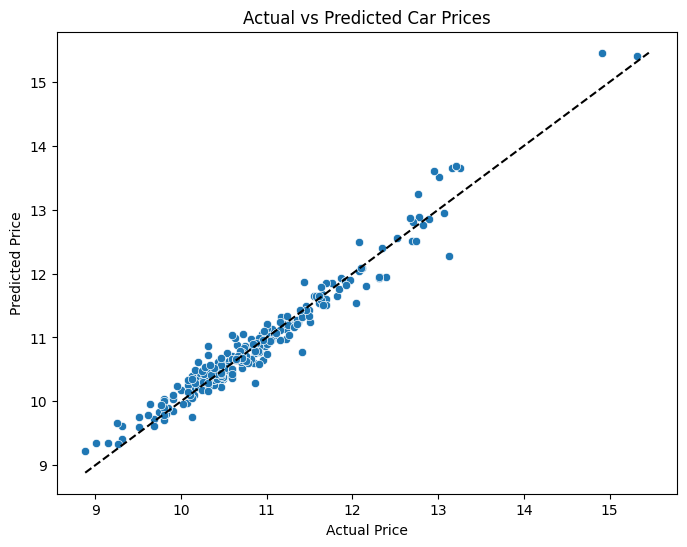

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=tuned_pred
)
min_value = min(y_test.min(), tuned_pred.min())
max_value = max(y_test.max(), tuned_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    color="black"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

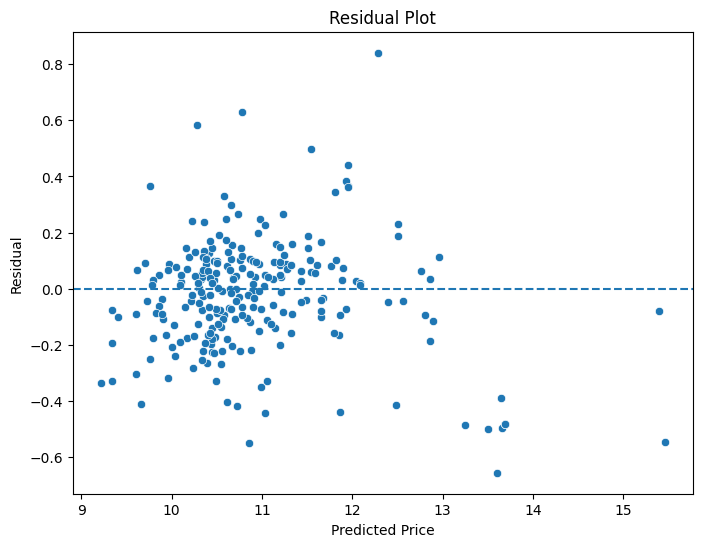

In [ ]:
residuals = y_test - tuned_pred
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=tuned_pred,
    y=residuals
)

plt.axhline(0, linestyle="--", color="Black")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [ ]:
preprocessor_fitted = best_model.named_steps["preprocessor"]

model = best_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(
    "importance",
    ascending=False
) 
feature_importance.head(20)

,feature,importance
0,num__horsepower,0.123400
2,num__torque,0.109170
7,num__acceleration_0_100,0.098949
1,num__total_speed,0.082090
3,num__engine_cc,0.075316
13,cat__company_names_Bugatti,0.033259
1590,cat__cc_battery_capacity_7993 cc,0.032915
1312,cat__engines_V12,0.031108
1261,cat__engines_8.0L Quad-Turbo W16,0.021212
1626,cat__seats_2,0.019903


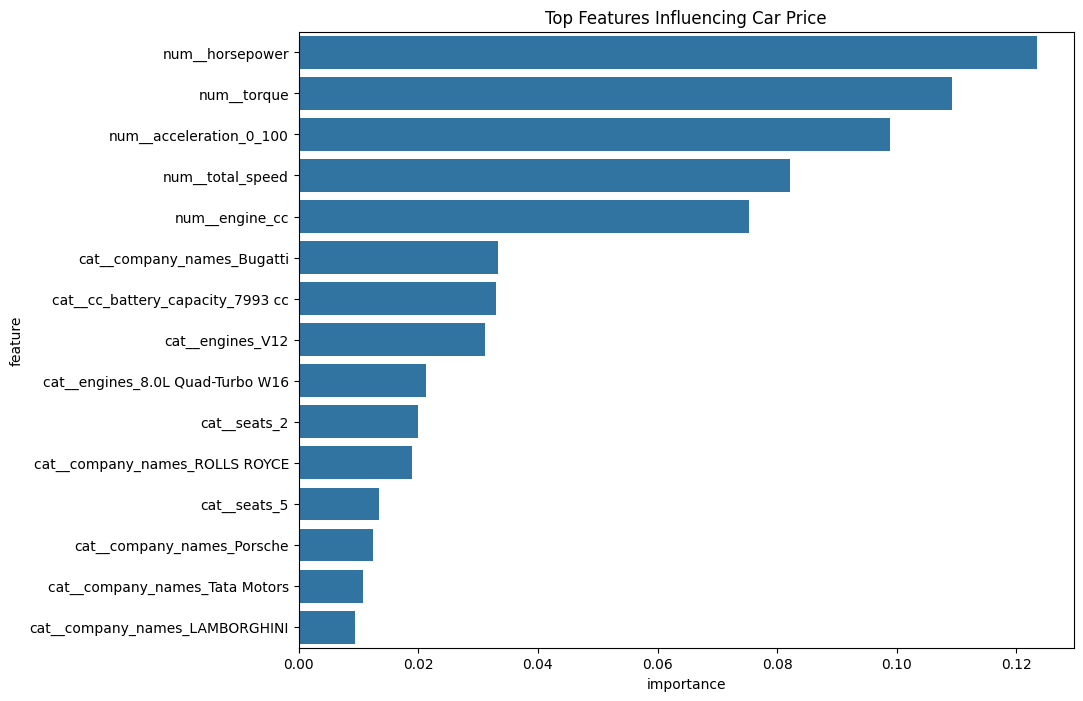

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Features Influencing Car Price")

plt.show()

In [ ]:
test_results = X_test.copy()

test_results["actual_price"] = y_test
test_results["predicted_price"] = tuned_pred

test_results["price_difference"] = (
    test_results["actual_price"]
    - test_results["predicted_price"]
)

brand_premium = (
    test_results
    .groupby("company_names")["price_difference"]
    .mean()
    .sort_values(ascending=False)
)